In [6]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [7]:
# C드라이브 D드라이브 어느 위치에 클론하든, 레포 안 어디에서 실행 방법()
data_dir = str(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / ".git").exists()) / "data" / "preprocessed")

X_path = fr"{data_dir}\cell2cell_train.csv"
y_path = fr"{data_dir}\cell2cell_train_churn.csv"

X = pd.read_csv(X_path)
y_df = pd.read_csv(y_path)

print("X:", X.shape)
print("y_df:", y_df.shape)

X.head()


X: (49776, 65)
y_df: (49776, 1)


,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,Prizm_Suburban,Prizm_Town,Occ_Clerical,Occ_Crafts,Occ_Homemaker,Occ_Other,Occ_Professional,Occ_Retired,Occ_Self,Occ_Student
0,-0.782676,-0.578738,-1.041153,-0.289532,-0.414422,-0.125914,-0.564836,-0.449987,-0.587303,-0.309284,...,1,0,0,0,0,0,1,0,0,0
1,-0.940180,-0.973177,-1.250809,-0.401714,-0.414422,-0.125914,0.029311,0.030120,-0.631532,-0.373230,...,1,0,0,0,0,0,1,0,0,0
2,-0.468118,-0.976952,-0.370255,-0.401714,-0.414422,-0.125914,0.037077,0.030120,-0.664703,-0.373230,...,0,1,0,1,0,0,0,0,0,0
3,0.526784,1.484048,1.181196,0.154708,-0.414422,-0.125914,0.654524,0.234797,5.085049,0.330172,...,0,0,0,0,0,1,0,0,0,0
4,-0.936810,-0.992050,-1.250809,-0.401714,-0.414422,-0.125914,0.044844,0.025066,-0.664703,-0.373230,...,0,0,0,0,0,0,1,0,0,0


In [8]:
y = pd.read_csv(y_path)["Churn"].astype(int)
print(y.value_counts(), y.value_counts(normalize=True))

Churn
0    35519
1    14257
Name: count, dtype: int64 Churn
0    0.713577
1    0.286423
Name: proportion, dtype: float64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)


X_train: (39820, 65) X_test: (9956, 65)


In [10]:
# lgbm = LGBMClassifier(
#    n_estimators=10000,
#    learning_rate=0.03,
#    random_state=42,
#    n_jobs=-1,
#    class_weight="balanced",
#    early_stopping_rounds=200,
#    verbose=1
#)

#lgbm.fit(
#    X_train, y_train,
#    eval_set=[(X_test, y_test)],
#    eval_metric="binary_logloss"
#)

In [11]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=10000,
    learning_rate=0.03,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric=["auc", "binary_logloss"],
    callbacks=[lgb.log_evaluation(1), lgb.early_stopping(200)]
)


[LightGBM] [Info] Number of positive: 11405, number of negative: 28415
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5012
[LightGBM] [Info] Number of data points in the train set: 39820, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[1]	training's auc: 0.654531	training's binary_logloss: 0.69087	valid_1's auc: 0.642467	valid_1's binary_logloss: 0.690951
Training until validation scores don't improve for 200 rounds
[2]	training's auc: 0.65576	training's binary_logloss: 0.688723	valid_1's auc: 0.642434	valid_1's binary_logloss: 0.688907
[3]	training's auc: 0.658333	training's binary_logloss: 0.686718	valid_1's auc: 0.645281	valid_1's binary_logloss: 0.686997
[4]	training's auc: 0.658871	training's binary_logloss: 0.684794	valid_1's

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,10000
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [12]:
proba = lgbm.predict_proba(X_test, num_iteration=lgbm.best_iteration_)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("thr=0.5")
print(classification_report(y_test, pred, zero_division=0))


ROC-AUC: 0.6832575804240425
thr=0.5
              precision    recall  f1-score   support

           0       0.81      0.60      0.69      7104
           1       0.40      0.66      0.50      2852

    accuracy                           0.62      9956
   macro avg       0.61      0.63      0.59      9956
weighted avg       0.70      0.62      0.64      9956



In [13]:
lgbm = LGBMClassifier(
    n_estimators=10000,
    learning_rate=0.03,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    reg_alpha=0.1
)


lgbm.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric=["auc", "binary_logloss"],
    callbacks=[
        lgb.log_evaluation(period=1),
        lgb.early_stopping(200, first_metric_only=True, verbose=True)
    ]
)

[LightGBM] [Info] Number of positive: 11405, number of negative: 28415
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005861 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5012
[LightGBM] [Info] Number of data points in the train set: 39820, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[1]	training's auc: 0.654531	training's binary_logloss: 0.690871	valid_1's auc: 0.642467	valid_1's binary_logloss: 0.690951
Training until validation scores don't improve for 200 rounds
[2]	training's auc: 0.655688	training's binary_logloss: 0.688726	valid_1's auc: 0.64256	valid_1's binary_logloss: 0.688908
[3]	training's auc: 0.658267	training's binary_logloss: 0.686721	valid_1's auc: 0.645404	valid_1's binary_logloss: 0.686995
[4]	training's auc: 0.658883	training's binary_logloss: 0.684798	valid_1'

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,10000
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [14]:
proba = lgbm.predict_proba(X_test, num_iteration=lgbm.best_iteration_)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("thr=0.5")
print(classification_report(y_test, pred, zero_division=0))

ROC-AUC: 0.6833273710246012
thr=0.5
              precision    recall  f1-score   support

           0       0.81      0.62      0.70      7104
           1       0.40      0.63      0.49      2852

    accuracy                           0.63      9956
   macro avg       0.61      0.63      0.60      9956
weighted avg       0.69      0.63      0.64      9956



In [15]:
lgbm = LGBMClassifier(
    n_estimators=10000,
    learning_rate=0.03,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    reg_alpha=0.1,
    reg_lambda=1.0
)


lgbm.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric=["auc", "binary_logloss"],
    callbacks=[
        lgb.log_evaluation(period=1),
        lgb.early_stopping(200, first_metric_only=True, verbose=True)
    ]
)

[LightGBM] [Info] Number of positive: 11405, number of negative: 28415
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007512 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5012
[LightGBM] [Info] Number of data points in the train set: 39820, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[1]	training's auc: 0.654456	training's binary_logloss: 0.690884	valid_1's auc: 0.642165	valid_1's binary_logloss: 0.690969
Training until validation scores don't improve for 200 rounds
[2]	training's auc: 0.656312	training's binary_logloss: 0.688746	valid_1's auc: 0.642688	valid_1's binary_logloss: 0.688932
[3]	training's auc: 0.658603	training's binary_logloss: 0.68675	valid_1's auc: 0.644583	valid_1's binary_logloss: 0.687026
[4]	training's auc: 0.6592	training's binary_logloss: 0.684834	valid_1's 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,10000
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [16]:
proba = lgbm.predict_proba(X_test, num_iteration=lgbm.best_iteration_)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred, zero_division=0))

ROC-AUC: 0.6830311805055406
              precision    recall  f1-score   support

           0       0.81      0.61      0.70      7104
           1       0.40      0.64      0.49      2852

    accuracy                           0.62      9956
   macro avg       0.60      0.63      0.60      9956
weighted avg       0.69      0.62      0.64      9956



earning_rate (0.01~0.08, log)
학습률은 배수(10배) 차이가 의미가 커서 로그 탐색이 효율적이고, 현재 0.03을 중심으로 너무 큰 값(0.1 이상)에서 성능이 튀는 걸 방지

num_leaves (16~128), max_depth (3~10)
트리의 복잡도를 조절하는 핵심 파라미터라서, 과적합/표현력을 균형 있게 조절할 수 있는 현실 범위

min_child_samples (20~200)
리프가 너무 잘게 쪼개지는 걸 막아 과적합을 줄이는 데 효과가 커서 포함, 데이터 상황에 따라 최적점이 크게 달라져 넓게 탐색

subsample / colsample_bytree (0.7~1.0)
행/열 샘플링으로 일반화를 높이는 용도. 너무 낮추면 성능이 불안정해질 수 있어 0.7 이상으로 제한

reg_alpha (1e-3~1.0, log), reg_lambda (1e-2~20.0, log)
L1/L2 규제 강도는 배수 변화가 중요해서 로그 탐색을 사용, 베이스라인(0.1/1.0) 주변에서 “규제가 거의 필요 없는 경우~꽤 필요한 경우”까지 커버하도록 범위를 설정

min_split_gain (0.0~0.2)
분할을 더 보수적으로 만들지(=쓸데없는 분할 억제) 조절해 과적합을 줄일 수 있어 보조적으로 포함

random_state=42
실험 결과 재현성을 확보하기 위해 고정

In [17]:
import optuna
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

def objective(trial):
    lgbm = LGBMClassifier(
        n_estimators=10000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        num_leaves=trial.suggest_int("num_leaves", 16, 128),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 200),
        subsample=trial.suggest_float("subsample", 0.7, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 20.0, log=True),
        min_split_gain=trial.suggest_float("min_split_gain", 0.0, 0.2),
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        verbose=-1
    )

    lgbm.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        eval_metric=["auc", "binary_logloss"],
        callbacks=[
            lgb.early_stopping(200, first_metric_only=True, verbose=False)
        ]
    )

    proba = lgbm.predict_proba(X_test, num_iteration=lgbm.best_iteration_)[:, 1]
    return roc_auc_score(y_test, proba)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("best_auc:", study.best_value)
print("best_params:", study.best_params)

[I 2026-02-23 17:26:45,471] A new study created in memory with name: no-name-44275868-d238-4418-9c4b-986ea1ffe401
[I 2026-02-23 17:26:50,399] Trial 0 finished with value: 0.6838247894633765 and parameters: {'learning_rate': 0.04405248527662806, 'num_leaves': 88, 'max_depth': 9, 'min_child_samples': 168, 'subsample': 0.7806891563343414, 'colsample_bytree': 0.9245311246470258, 'reg_alpha': 0.008288470358704001, 'reg_lambda': 0.2480771583919126, 'min_split_gain': 0.04952704364425682}. Best is trial 0 with value: 0.6838247894633765.
[I 2026-02-23 17:26:55,404] Trial 1 finished with value: 0.6836731158314695 and parameters: {'learning_rate': 0.061568665107558956, 'num_leaves': 115, 'max_depth': 7, 'min_child_samples': 81, 'subsample': 0.8338039947759105, 'colsample_bytree': 0.9939615755653513, 'reg_alpha': 0.0021762104785313114, 'reg_lambda': 6.71717985765218, 'min_split_gain': 0.02688672778125223}. Best is trial 0 with value: 0.6838247894633765.
[I 2026-02-23 17:27:05,588] Trial 2 finished

best_auc: 0.6872293269777491
best_params: {'learning_rate': 0.012626448344001213, 'num_leaves': 94, 'max_depth': 7, 'min_child_samples': 47, 'subsample': 0.8226659257269393, 'colsample_bytree': 0.7937491477593271, 'reg_alpha': 0.12041839957917566, 'reg_lambda': 2.6001649284617434, 'min_split_gain': 0.026238645022056396}


In [18]:
best_params = study.best_params

lgbm = LGBMClassifier(
    n_estimators=10000,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    **best_params,
    verbose=-1
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric=["auc", "binary_logloss"],
    callbacks=[
        lgb.early_stopping(200, first_metric_only=True, verbose=False)
    ]
    )

proba = lgbm.predict_proba(X_test, num_iteration=lgbm.best_iteration_)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred, zero_division=0))

ROC-AUC: 0.6872293269777491
              precision    recall  f1-score   support

           0       0.81      0.63      0.71      7104
           1       0.41      0.64      0.50      2852

    accuracy                           0.63      9956
   macro avg       0.61      0.63      0.60      9956
weighted avg       0.70      0.63      0.65      9956



In [19]:
model = lgbm
print("Train Accuarcy Score is :",model.score(X_train, y_train))
print("Test Accuarcy Score is  :", model.score(X_test, y_test))

Train Accuarcy Score is : 0.7101707684580613
Test Accuarcy Score is  : 0.631478505423865


In [20]:
fesat_impt_ser = pd.Series(
    lgbm.booster_.feature_importance(importance_type="gain"),
    index=lgbm.booster_.feature_name()
).sort_values(ascending=False)

top10_feat_impt = fesat_impt_ser.sort_values(ascending=False).head(10)

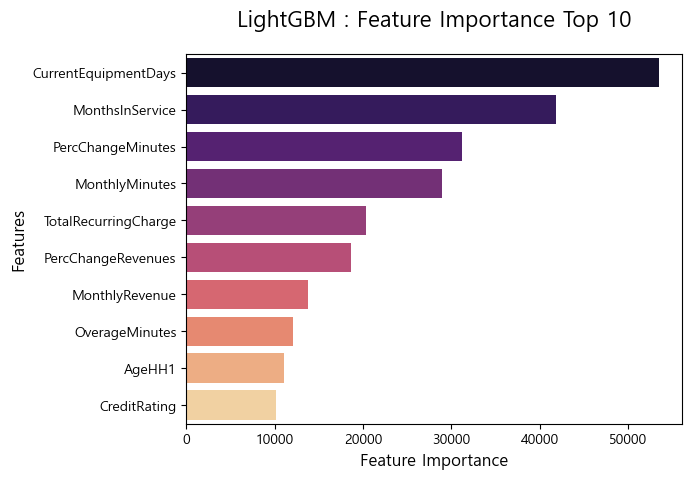

In [21]:
import seaborn as sns
import os

# 그래프 저장할 파일 저장 경로
repo_root = r"D:\GIT\SKN24-2nd-6Team"
out_dir = os.path.join(repo_root, "asset", "graph")

sns.barplot(
    x=top10_feat_impt,
    y=top10_feat_impt.index,
    hue=top10_feat_impt.index,
    palette='magma' # 좀 더 강렬한 색상 팔레트
)

# 막대 옆에 수치 표시
# for i, v in enumerate(top7_feat_impt):
#    plt.text(v, i, f' {v:.4f}', va='center', fontweight='bold', fontsize=7)

plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('LightGBM : Feature Importance Top 10', fontsize=16, pad=20)

os.makedirs(out_dir, exist_ok=True)

plt.savefig(os.path.join(out_dir, "LGBM_balanced_feature_importance_optuna.png"),
            dpi=300, bbox_inches="tight")

plt.show()

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.63      0.71      7104
           1       0.41      0.64      0.50      2852

    accuracy                           0.63      9956
   macro avg       0.61      0.63      0.60      9956
weighted avg       0.70      0.63      0.65      9956



In [23]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = model.predict(X_test)
print("              RF Classification Report")
print(classification_report(y_test, y_pred))

              RF Classification Report
              precision    recall  f1-score   support

           0       0.81      0.63      0.71      7104
           1       0.41      0.64      0.50      2852

    accuracy                           0.63      9956
   macro avg       0.61      0.63      0.60      9956
weighted avg       0.70      0.63      0.65      9956



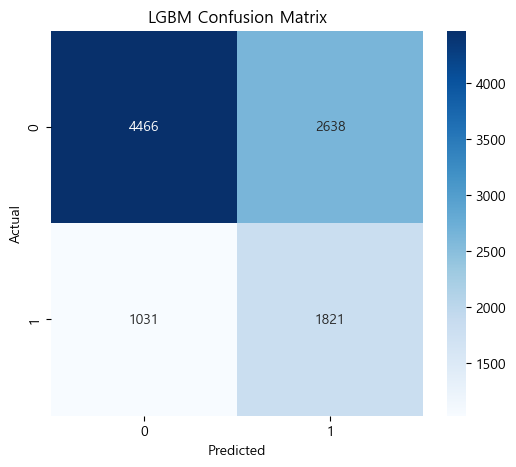

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LGBM Confusion Matrix')

plt.savefig(os.path.join(out_dir, "LGBM_confusin_matrix_optuna.png"),
            dpi=300, bbox_inches="tight")

plt.show()

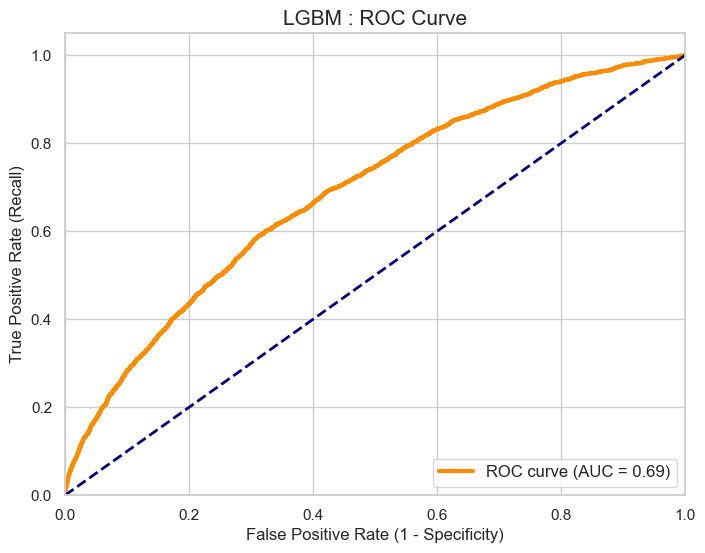

0.6872293269777491


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

pred_proba_1 = lgbm.predict_proba(X_test)[:, 1]

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(y_test, pred_proba_1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('LGBM : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig(os.path.join(out_dir, "LGBM_ROC_Curve_optuna.png"),
            dpi=300, bbox_inches="tight")

plt.show()


print(roc_auc)